<a href="https://colab.research.google.com/github/pratham-magar-13/PyTorch-Tutorial/blob/main/Multiclass_Classification_Problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Putting it all together with a multi-class classificatin problem**
* Binary classification - one thing or another (cat vs dog, spam vs not spam)
* Multi-class classification - more than one thing or another(cat v dog v parrot)

#**Creating a toy multi-class dataset**

In [ ]:
# import dependencies
import torch
import matplotlib.pyplot as plt
from torch import nn
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

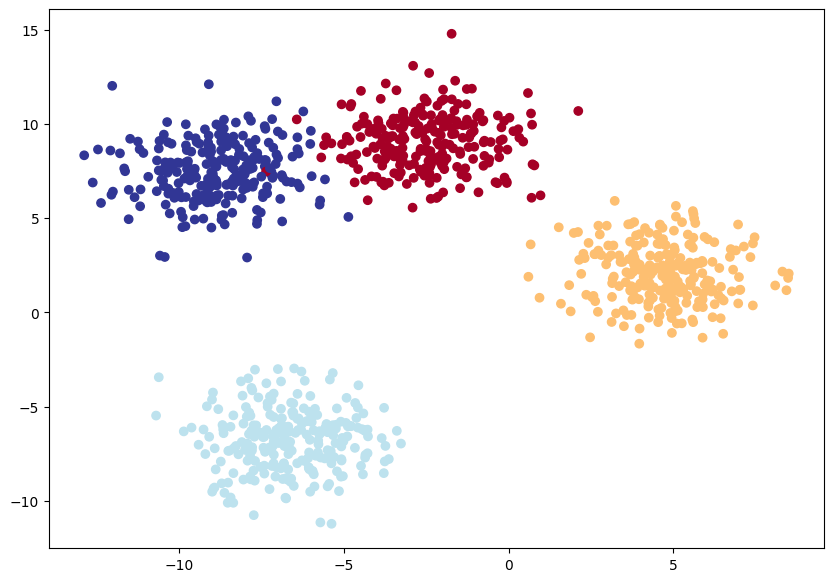

In [ ]:
# set the hyperparameters for data creation
NUM_CLASSES=4
NUM_FEATURES=2
RANDOM_SEED=42

# Create multi class data
X_blob, y_blob = make_blobs(n_samples=1000,
                            n_features=NUM_FEATURES,
                            centers=NUM_CLASSES,
                            cluster_std=1.5,
                            random_state=RANDOM_SEED)

# Turn the data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

# Split in to train and test
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
                                                                        y_blob,
                                                                        test_size=0.2,
                                                                        random_state=RANDOM_SEED)


# Plot the data
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu)

#**Building a multi-class classification model in PyTorch**

In [ ]:
# Create device agnostic code
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
# Build a multi-class classification model
class BlobModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units=8):
    super().__init__()
    self.Linear_layer_stack=nn.Sequential(
        nn.Linear(in_features=input_features, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_features))
  def forward(self, x):
    return self.Linear_layer_stack(x)


# Create an instance of BlobModel and send it to the target device
model_1=BlobModel(input_features=2,
                  output_features=4,
                  hidden_units=8).to(device)
model_1

BlobModel(
  (Linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [ ]:
X_blob_train.shape, y_blob_train[:5]

(torch.Size([800, 2]), tensor([1, 0, 2, 2, 0]))

#**Create a loss function and an optimizer for a multi-class classification model**

In [ ]:
loss_fn = nn.CrossEntropyLoss()

optimizer=torch.optim.SGD(params=model_1.parameters(),lr=0.1)

#**Getting prediction probabilities for a multi-class PyTorch model**

In order to evaluate and train and test ourmodel, we need to convert our model's  outputs(logits) to prediction probabilities and then to prediction labels.


logits->pred probs->pred labels


In [ ]:
# let's get some raw outputs of our model (logits)
model_1.eval()
with torch.inference_mode():
  y_logits=model_1(X_blob_test.to(device))
y_logits

tensor([[ 0.7111, -0.5330,  0.3307, -0.2327],
        [-0.3420, -1.7850, -0.3224, -1.1384],
        [ 0.1878, -0.8563,  0.3375, -0.9026],
        [ 0.4513, -0.4277,  0.2498, -0.1940],
        [ 0.8922, -0.9492,  0.3245, -0.5287],
        [-0.4885, -2.0119, -0.4004, -1.3252],
        [ 0.2586, -0.8477,  0.2739, -0.8695],
        [ 0.6816, -1.1144,  0.2053, -0.6434],
        [ 0.3433, -1.0156,  0.4706, -1.1226],
        [ 0.7687, -1.0243,  0.2629, -0.5887],
        [ 0.4952, -1.2227,  0.1091, -0.7200],
        [ 0.7219, -0.5537,  0.3312, -0.2466],
        [ 0.8856, -0.9787,  0.3213, -0.5593],
        [ 0.7945, -1.1402,  0.2451, -0.6579],
        [ 0.8772, -1.1311,  0.2811, -0.6518],
        [-0.1531, -1.6311, -0.2211, -1.0243],
        [-0.3745, -1.8111, -0.3247, -1.1763],
        [ 0.4334, -0.7248,  0.4582, -0.7560],
        [-0.2584, -1.9204, -0.3248, -1.2143],
        [-0.2770, -1.6132, -0.1307, -1.1863],
        [-0.0825, -1.7034, -0.2113, -1.0648],
        [ 0.5446, -1.0562,  0.1647

In [ ]:
y_blob_test

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
        2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
        0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 0, 3, 2, 0, 0, 3, 0, 2, 3, 1, 0, 3, 2, 1, 1, 0, 2, 2, 3, 0, 0, 1, 2,
        2, 3, 0, 1, 2, 0, 0, 0, 2, 3, 1, 2, 3, 2, 0, 3, 0, 0, 1, 1, 1, 0, 2, 2,
        2, 2, 0, 3, 3, 2, 2, 1, 3, 2, 0, 0, 3, 3, 2, 1, 2, 0, 3, 2, 0, 3, 2, 0,
        2, 2, 2, 0, 3, 1, 1, 1, 1, 1, 3, 1, 0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 0,
        1, 3, 2, 0, 3, 1, 2, 1])

In [ ]:
# convert our model's logit outputs to prediction probabilities
y_pred_probs=torch.softmax(y_logits, dim=1)
y_pred_probs

tensor([[0.4236, 0.1221, 0.2895, 0.1648],
        [0.3694, 0.0873, 0.3767, 0.1666],
        [0.3509, 0.1235, 0.4076, 0.1179],
        [0.3627, 0.1506, 0.2965, 0.1902],
        [0.5084, 0.0806, 0.2882, 0.1228],
        [0.3645, 0.0795, 0.3981, 0.1579],
        [0.3745, 0.1239, 0.3803, 0.1212],
        [0.4871, 0.0808, 0.3025, 0.1295],
        [0.3812, 0.0979, 0.4329, 0.0880],
        [0.4934, 0.0821, 0.2975, 0.1270],
        [0.4639, 0.0832, 0.3153, 0.1376],
        [0.4282, 0.1196, 0.2897, 0.1626],
        [0.5103, 0.0791, 0.2903, 0.1203],
        [0.5113, 0.0739, 0.2952, 0.1197],
        [0.5258, 0.0706, 0.2897, 0.1140],
        [0.3875, 0.0884, 0.3620, 0.1621],
        [0.3653, 0.0869, 0.3840, 0.1639],
        [0.3783, 0.1188, 0.3878, 0.1151],
        [0.3984, 0.0756, 0.3728, 0.1532],
        [0.3542, 0.0931, 0.4100, 0.1427],
        [0.4080, 0.0807, 0.3586, 0.1528],
        [0.4545, 0.0917, 0.3108, 0.1430],
        [0.3596, 0.1497, 0.3042, 0.1866],
        [0.3446, 0.1364, 0.3833, 0

In [ ]:
# convert our model's prediction probabilities to prediction labels
y_preds=torch.argmax(y_pred_probs, dim=1)
y_preds

tensor([0, 2, 2, 0, 0, 2, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 2, 0, 0, 0, 2,
        2, 2, 2, 0, 0, 0, 2, 0, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 2, 2, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 2, 2, 2, 0, 2, 2, 2, 0, 0, 0, 2, 0, 0, 0,
        2, 0, 2, 2, 2, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2,
        0, 0, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 2, 2, 0, 0, 0, 0, 2,
        2, 2, 0, 0, 2, 0, 0, 0, 2, 2, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2,
        2, 2, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0, 0, 0, 2, 0, 2, 0, 2, 2, 0, 2, 2, 0,
        2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 2, 2, 0, 2, 2, 0, 0, 2, 2, 0, 0,
        0, 2, 2, 0, 2, 0, 2, 0])

#**Creating a training loop and testing loop for a multi-class PyTorch model**

In [ ]:
# Fit the multi-class model to the data
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs=100

# put data to the target device
X_blob_train, y_blob_train=X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test=X_blob_test.to(device), y_blob_test.to(device)

# loop through the data
for epoch in range(epochs):
  ### Training
  model_1.train()
  y_logits=model_1(X_blob_train).to(device)
  y_pred=torch.softmax(y_logits, dim=1).to(device)


  loss=loss_fn(y_logits, y_blob_train)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  ### Testing
  model_1.eval()
  with torch.inference_mode():
    test_logits=model_1(X_blob_test).to(device)
    test_pred=torch.softmax(test_logits, dim=1).to(device)
    test_loss=loss_fn(test_logits, y_blob_test)
  # print out what's happening
  if epoch % 10 == 0:
   print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")

Epoch: 0 | Loss: 0.028202082961797714 | Test Loss: 0.017620505765080452
Epoch: 10 | Loss: 0.02812868356704712 | Test Loss: 0.017496883869171143
Epoch: 20 | Loss: 0.02805856056511402 | Test Loss: 0.017376476898789406
Epoch: 30 | Loss: 0.02799135260283947 | Test Loss: 0.01726139523088932
Epoch: 40 | Loss: 0.02792682871222496 | Test Loss: 0.017148613929748535
Epoch: 50 | Loss: 0.02786468341946602 | Test Loss: 0.017056234180927277
Epoch: 60 | Loss: 0.02780485339462757 | Test Loss: 0.016962150111794472
Epoch: 70 | Loss: 0.02774711884558201 | Test Loss: 0.016866546124219894
Epoch: 80 | Loss: 0.02769104205071926 | Test Loss: 0.016753695905208588
Epoch: 90 | Loss: 0.027636732906103134 | Test Loss: 0.016674093902111053


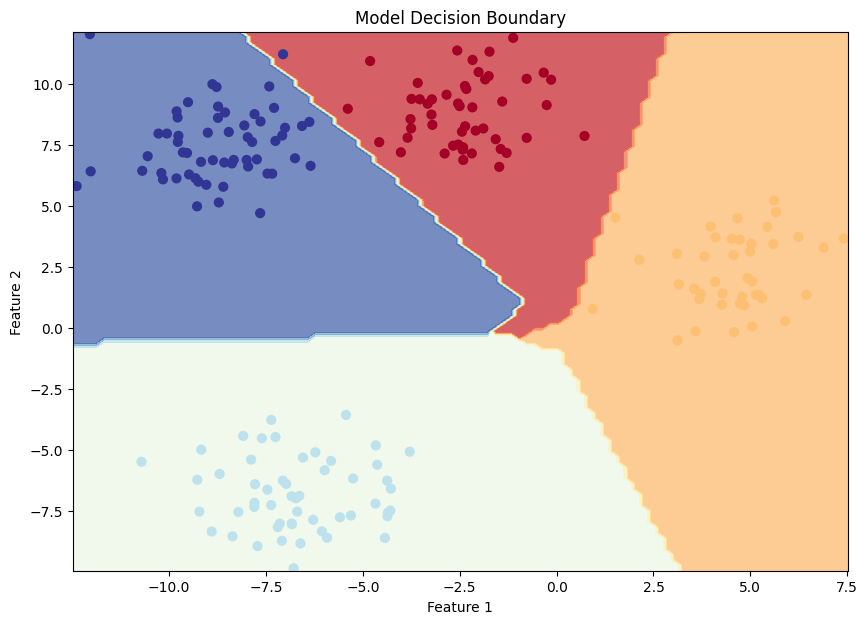

In [ ]:
import numpy as np

# Make predictions
model_1.eval()
with torch.inference_mode():
    y_logits = model_1(X_blob_test).to(device)

# Calculate accuracy (if you want)
# y_pred_labels = torch.argmax(y_logits, dim=1)
# accuracy = (y_pred_labels == y_blob_test).float().mean() * 100
# print(f"Test Accuracy: {accuracy:.2f}%")

# Visualize the decision boundary
def plot_decision_boundary(model, X, y):
    # Put everything to CPU (since matplotlib runs on CPU)
    X, y = X.cpu(), y.cpu()

    # Setup prediction boundaries and meshgrid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                           np.linspace(y_min, y_max, 100))

    # Make features for prediction
    X_to_predict_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_predict_on.to(device))

    # Convert logits to prediction probabilities
    y_pred_probs = torch.softmax(y_logits, dim=1)
    # Convert prediction probabilities to prediction labels
    y_pred_labels = torch.argmax(y_pred_probs, dim=1)

    # Reshape predictions:
    y_pred_labels = y_pred_labels.reshape(xx.shape).cpu().numpy()

    # Plot the data
    plt.figure(figsize=(10, 7))
    plt.contourf(xx, yy, y_pred_labels, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.title("Model Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

plot_decision_boundary(model_1, X_blob_test, y_blob_test)
